In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hcipy as hci
import pandas as pd
import utils
import time


![Gemini_Generated_Image_jh67bjjh67bjjh67 (1).png](<attachment:Gemini_Generated_Image_jh67bjjh67bjjh67 (1).png>)

### pupil/ telescope params :
- telescope diam. 
- central obscuration : the diam. of the block in the middle of the pupil
- central obscuration ratio
- spider width : the arms/handles that hold the obscuration in place 
- oversizing factor : 

aperture params

In [2]:
# wavelength = 500e-9
wavelength = 1550e-9

# physical measurements
telescope_diameter = 8.0       # [m]
central_obscuration = 1.2      # [m]
central_obscuration_ratio = central_obscuration / telescope_diameter
spider_width = 0.05            # [m]

using the specifications to create the aperture generator :

- telescope diameter
- central obrcuration - circle in the center that is the view block of the mirror
- num spiders - the legs holding the mirror
- spider width - theyre width


In [3]:
VLT_aperture_generator = hci.make_obstructed_circular_aperture(
    telescope_diameter,
    central_obscuration_ratio,
    num_spiders=4,
    spider_width=spider_width
)

pupil grid params and instance

In [4]:
# simulation auxillary
oversizing_factor = 16.0 / 15.0
num_pupil_pixels_base = 240
num_pupil_pixels = int(num_pupil_pixels_base * oversizing_factor)  # must be int
pupil_grid_diameter = telescope_diameter * oversizing_factor
# pupil_grid = hci.make_pupil_grid(num_pupil_pixels_base, pupil_grid_diameter)
pupil_grid = hci.make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)
pupil_grid.shape

array([256, 256])

focal grid params and instance

In [5]:
q = 4
num_airy = 50
focal_spatial_resolution = wavelength / telescope_diameter
focal_grid = hci.make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=focal_spatial_resolution)
focal_grid.shape

array([400, 400])

creating an instance of an aperture field

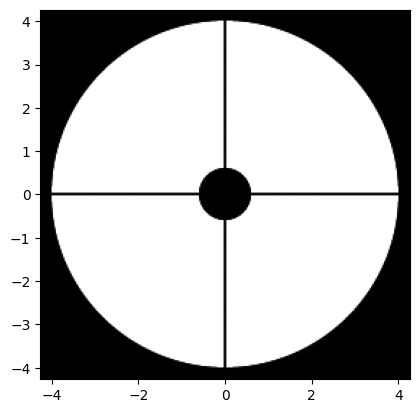

In [6]:
sampling_rate = 4
aperture = hci.evaluate_supersampled(VLT_aperture_generator,pupil_grid,4)
wf_aperture = hci.Wavefront(aperture,wavelength)
wf_aperture.total_power = 1.0
hci.imshow_field(wf_aperture.power,cmap = "gray")

propagate the wavefront through the pupil creates the psf

In [7]:
propagator = hci.FraunhoferPropagator(pupil_grid,focal_grid)
psf_aperture = propagator.forward(wf_aperture).power
psf_aperture.total_power = 1.0

c:\Users\yizha\qkd\.venv\Lib\site-packages\hcipy\fourier\naive_fourier_transform.py:168: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_multiplications = input_grid.size * output_grid.size
c:\Users\yizha\qkd\.venv\Lib\site-packages\hcipy\fourier\naive_fourier_transform.py:169: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_additions = (input_grid.size - 1) * output_grid.size
c:\Users\yizha\qkd\.venv\Lib\site-packages\hcipy\fourier\naive_fourier_transform.py:171: RuntimeWarning: overflow encountered in scalar multiply
  num_multiplications = 4 * num_complex_multiplications
c:\Users\yizha\qkd\.venv\Lib\site-packages\hcipy\fourier\naive_fourier_transform.py:172: RuntimeWarning: overflow encountered in scalar multiply
  num_additions = 2 * num_complex_multiplications + 2 * num_complex_additions


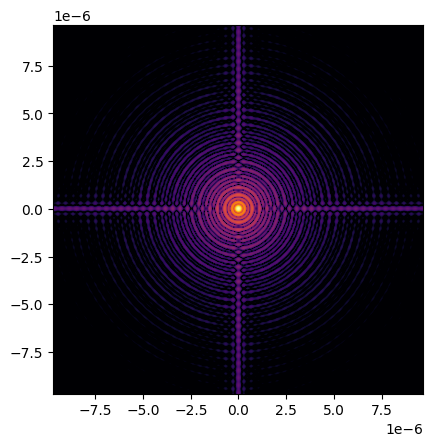

In [8]:
im = np.log10(psf_aperture/psf_aperture.max())
hci.imshow_field(im,cmap="inferno",vmin=-6,vmax=0)

atmosphere layer

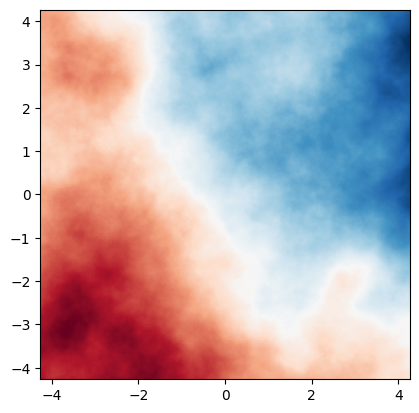

In [9]:
r0 = 2.0
wavelength_ref = 500e-9
L0 = 50.0
r0_ref_500nm = r0 * (wavelength/wavelength_ref)**(6.0/5.0)
Cn2 = hci.Cn_squared_from_fried_parameter(r0_ref_500nm,wavelength)

atmosphere = hci.InfiniteAtmosphericLayer(pupil_grid,Cn2,L0=L0,velocity=0)
phase_screen = atmosphere.phase_for(wavelength)

hci.imshow_field(phase_screen,cmap= "RdBu")

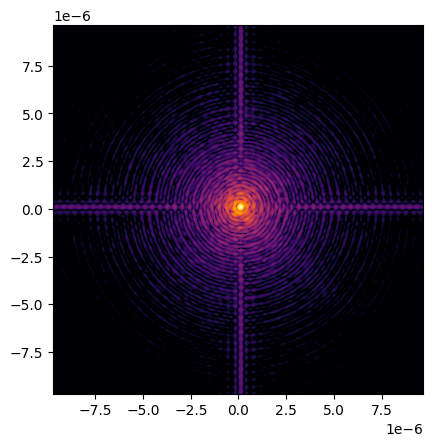

In [10]:
wf_turb = atmosphere(wf_aperture)
wf_turb_prop = propagator.forward(wf_turb)
psf_turb = wf_turb_prop.power
psf_turb.total_power = 1.0
im = np.log10(psf_turb/psf_turb.max())
hci.imshow_field(im,cmap="inferno",vmin=-6,vmax=0)

-21.766751641997537


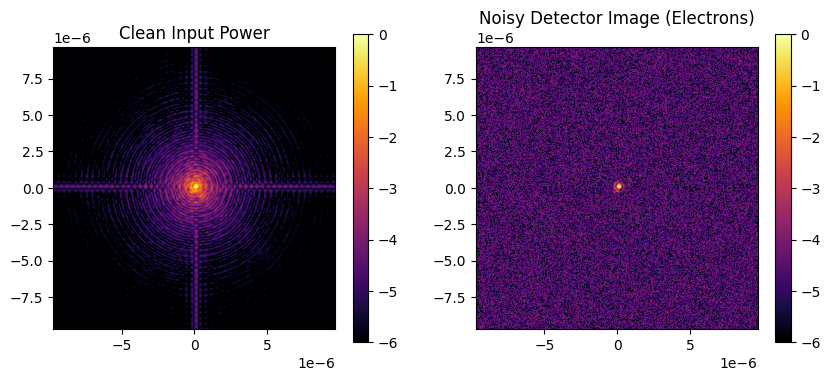

In [ ]:
# Get the noisy image from your function
noisy_image = utils.add_noise_to_wavefront(wf_turb_prop, telescope_diameter,stellar_magnitude=14)
psf_like = lambda x : np.log10(x/x.max())
print(noisy_image.min())
# Plotting
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
hci.imshow_field(psf_like(wf_turb_prop.intensity),cmap = "inferno",vmax=0,vmin=-6)
plt.title("Clean Input Power")
plt.colorbar()

plt.subplot(1, 2, 2)
hci.imshow_field(psf_like(abs(noisy_image)**2),cmap = "inferno",vmax=0,vmin=-6)
plt.title("Noisy Detector Image (Electrons)")
plt.colorbar()

In [ ]:
# df = pd.read_csv("./massive_output.csv")
# df
# cols = ["wavelength",
# "r0_ref",
# "run_number",

# "power_in_bucket_before_turbulance",
# "total_power_before_turbulance",
# "precentage_before_turbulance",

# "power_in_bucket_after_turbulance",
# "total_power_after_turbulance",
# "precentage_after_turbulance",

# "time"
# ]
# df.head()

,wavelength,r0_ref,run_number,focsl_dim,power_in_bucket_before_turbulance,total_power_before_turbulance,precentage_before_turbulance,power_in_bucket_after_turbulance,total_power_after_turbulance,precentage_after_turbulance,...,0,9e-06,15269597917631.41,1853383177720091.5,0.008238770104957494,1367261530461.9023,184697341917520.44,0.007402713630131585,382665985320918.6,2025-11-06 14:07:38
0,0.000002,0.01,1,8,0.573206,48.018891,0.011937,0.000048,44.210089,0.000001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000002,0.01,2,8,0.573206,48.018891,0.011937,0.000201,44.471248,0.000005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000002,0.01,3,8,0.573206,48.018891,0.011937,0.000194,44.447986,0.000004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000002,0.01,4,8,0.573206,48.018891,0.011937,0.000247,44.276890,0.000006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.000002,0.01,5,8,0.573206,48.018891,0.011937,0.000110,44.545820,0.000002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
